In [1]:
# !pip install pennylane
# !pip install pennylane pennylane-lightning[gpu]

In [2]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import StronglyEntanglingLayers
import torch
import matplotlib.pyplot as plt
from torch.nn.functional import relu
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from skimage.transform import resize

/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


### Dataset Preparation


First, we load the MNIST dataset from openML.
- X is the pixel data
- y is the labels
- converting everything to `uint8` here to ensure all values are integers in [0, 255]

In [3]:
# loading mnist from keras.datasets
from keras.datasets import mnist
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()
X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)

X = X.astype(np.uint8) # better to convert for binerization
y = y.astype(np.uint8)
# digits = load_digits()

# X = digits.data        # shape (1797, 64)
# y = digits.target      # labels 0–9


2026-03-11 15:02:33.471004: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
X.shape

(70000, 28, 28)

Next, we focus on 2 classes, i.e. binary classification.
Here, I've been experimenting with different classes, and I stopped on 4 vs 9, cause they have more subtle difference in pixels, they are similar looking.

In [5]:
# focus on binary classification
mask = (y == 0) | (y == 1)

X, y = X[mask], y[mask]
X.shape

(14780, 28, 28)

In [6]:
print("Unique labels:", np.unique(y))

Unique labels: [0 1]


In [7]:
y = np.where(y == 0, -1, 1)
print("Unique labels:", np.unique(y))

Unique labels: [-1  1]


- I take only the first `n_samples`.
- I convert X to a NumPy array, and shuffling the data randomly

In [8]:
n_samples = 360 # restricting to 6000 samples for now

X = X.values if hasattr(X, "values") else X # safer conversion

X = X[:n_samples]
y = y[:n_samples]

Now, I normalise pixel intensities.
- [0, 255] -> [0, 1]
- reshaping images back to 2D for resizing, i.e to 28x28 array with float values between 0 and 1.

In [9]:
X = X / 255.0
X = X.reshape(-1, 28, 28)

print(X.shape)
print("Pixel range:", X.min(), X.max())

(360, 28, 28)
Pixel range: 0.0 1.0


And now I reduce images to 8x8 + flattening to (, 64)
- resize -> flatten -> normalize

In [10]:
# convert each 28x28 binarised image to 8x8, then flatten to length 64
def to_8x8_vector(img_row):
    img_8x8 = resize(
        img_row,
        (8, 8),
        anti_aliasing=False,
        preserve_range=True,
        order=1 # controlling interpolation
    )
    img_8x8 = img_8x8.flatten().astype(float)
    # img_8x8 -= img_8x8.mean()
    norm = np.linalg.norm(img_8x8)
    if norm > 0:
        img_8x8 /= norm
    else:
        img_8x8[0] = 1.0
      # should be shape (64,)
    return img_8x8

# apply transformation to all images
X_8x8 = np.array([to_8x8_vector(x) for x in X], dtype=float)
X_8x8.shape

(360, 64)

In [11]:
# sanity check, make sure no NaNs exist and all vectors are normalised, i.e. norm is around 1
print("Any NaNs?", np.isnan(X_8x8).any())
print("Norm check:", np.min(np.linalg.norm(X_8x8, axis=1)), np.max(np.linalg.norm(X_8x8, axis=1)))

Any NaNs? False
Norm check: 0.9999999999999998 1.0000000000000002


I'm gonna do the splitting here, and carry both representations consistently.
- qek inputs: (64,) flattened and normalized vectors, for quantum kernel embedding
- qjpeg: 28x28 images

In [12]:
idx = np.arange(n_samples)

idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

# QEK inputs (8x8 -> 64 -> normed)
X_train_qek = X_8x8[idx_train]
X_test_qek  = X_8x8[idx_test]

print("QEK train/test:", X_train_qek.shape, X_test_qek.shape)
print("Labels train/test:", y_train.shape, y_test.shape)

QEK train/test: (288, 64) (72, 64)
Labels train/test: (288,) (72,)


Data preparation is done.

### Device

In [13]:
### Device

import pennylane.transforms as transforms
print(dir(transforms))

import pennylane as qml
from pennylane import numpy as qnp
from pennylane.noise import mitigate_with_zne, richardson_extrapolate, fold_global, poly_extrapolate
from functools import partial

# Define a new device class by inheriting from the existing device class
class MyMixedDevice(qml.devices.DefaultMixed):
    def __init__(self, noise_strength, wires, **kwargs):
        super().__init__(wires=wires, **kwargs)
        self.noise_strength = noise_strength

    def apply(self, operations, **kwargs):
        # Apply the DepolarizingChannel noise to each operation
        for operation in operations:
            if isinstance(operation, qml.operation.Observable):
                self.noise_strength = operation.parameters[0] if operation.name == "DepolarizingChannel" else self.noise_strength
                if isinstance(operation, qml.operation.Expectation):
                    operation.return_type = qml.operation.Expectation
        return super().apply(operations, **kwargs)

n_qubits = 6
dev_ideal = qml.device('default.mixed', wires=n_qubits)
dev_mixed = MyMixedDevice(0.05, wires=range(n_qubits))

['CommutationDAG', 'CommutationDAGNode', 'CompilePipeline', 'TransformError', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'apply_controlled_Q', 'batch_input', 'batch_params', 'batch_partial', 'broadcast_expand', 'cancel_inverses', 'clifford_t_decomposition', 'combine_global_phases', 'commutation_dag', 'commute_controlled', 'commute_ppr', 'compile', 'convert_to_numpy_parameters', 'core', 'create_decomp_expand_fn', 'create_expand_fn', 'create_expand_trainable_multipar', 'decompose', 'decompose_arbitrary_ppr', 'decompositions', 'defer_measurements', 'diagonalize_measurements', 'dynamic_one_shot', 'expand_invalid_trainable', 'expand_multipar', 'expand_nonunitary_gen', 'expand_trainable_multipar', 'from_zx', 'gridsynth', 'intermediate_reps', 'is_mcm', 'make_tape', 'match_controlled_iX_gate', 'match_relative_phase_toffoli', 'merge_amplitude_embedding', 'merge_ppr_ppm', 'merge_rotations', 'optimization', 'parity_matrix'

### Quantum Model

In [18]:
def qek_layer_amplitude(x, theta):
    # Data re-uploading via phase gates (breaks kernel symmetry)
    wires = range(n_qubits)
    for l in range(theta.shape[0]):
        i = 0
        for j, wire in enumerate(wires):
            qml.Hadamard(wires=[wire])
            qml.RZ(x[i % len(x)], wires=[wire])
            i += 1
            qml.RY(theta[l, j, 0], wires=wire)

        # Trainable block
        for q in range(n_qubits):
            qml.CRZ(theta[l, q, 0], wires=[q % n_qubits, (q + 1) % n_qubits])

def qek_embedding_amplitude(x, theta):
    qml.AmplitudeEmbedding(
        x,
        wires=range(n_qubits),
        normalize=False
    )
    qek_layer_amplitude(x, theta)

# Applying the transform with functools.partial
mitigated_qnode = partial(mitigate_with_zne, scale_factors=[1, 2, 3], folding=fold_global, extrapolate=richardson_extrapolate)

@mitigated_qnode
@qml.qnode(dev_mixed)
def quantum_model(x, params):
    """A variational quantum model."""
    qek_embedding_amplitude(x, params)
    # trainable measurement
    StronglyEntanglingLayers(params, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

def quantum_model_plus_bias(x, params, bias):
    """Adding a bias."""
    return quantum_model(x, params) + bias

def hinge_loss(predictions, targets):
    """Implements the hinge loss."""
    all_ones = torch.ones_like(targets)
    hinge_loss = all_ones - predictions * targets
    # trick: since the max(0,x) function is not differentiable,
    # use the mathematically equivalent relu instead
    hinge_loss = relu(hinge_loss)
    return hinge_loss

def kta_loss_full(theta, X, y):
    def _kernel(x1, x2):
        return qek_kernel(x1, x2, theta)
    return -qml.kernels.target_alignment(X_train_qek, y_train, kernel=_kernel)

def kta_loss_minibatch(theta, X, y, batch_size=8):
    idx = np.random.choice(len(X), batch_size, replace=False)
    Xb = X[idx]
    yb = y[idx]

    # Define a kernel function that takes x1, x2 and uses the current theta
    def _kernel_fn(x1, x2):
        return qek_kernel(x1, x2, theta)

    # PennyLane's KTA
    return -qml.kernels.target_alignment(Xb, yb, kernel=_kernel_fn)

def quantum_model_train(n_layers, steps, batch_size):
    """Train the quantum model defined above."""

    params = np.random.random((n_layers, n_qubits, 3))
    params_torch = torch.tensor(params, requires_grad=True)
    bias_torch = torch.tensor(0.0, requires_grad=True)

    opt = torch.optim.Adam([params_torch, bias_torch], lr=0.1)

    loss_history = []
    for i in range(steps):

        batch_ids = np.random.choice(len(X_train_qek), batch_size)

        X_batch = X_train_qek[batch_ids]
        y_batch = y_train[batch_ids]

        X_batch_torch = torch.tensor(X_batch, requires_grad=False)
        y_batch_torch = torch.tensor(y_batch, requires_grad=False)

        def closure():
            opt.zero_grad()
            preds = torch.stack(
                [quantum_model_plus_bias(x, params_torch, bias_torch) for x in X_batch_torch]
            )
            loss = torch.mean(hinge_loss(preds, y_batch_torch))

            # bookkeeping
            current_loss = loss.detach().numpy().item()
            loss_history.append(current_loss)
            print("step", i, ", loss", current_loss)

            loss.backward()
            return loss

        opt.step(closure)

    return params_torch, bias_torch, loss_history


def quantum_model_predict(X_pred, trained_params, trained_bias):
    """Predict using the quantum model defined above."""

    p = []
    for x in X_pred:

        x_torch = torch.tensor(x)
        pred_torch = quantum_model_plus_bias(x_torch, trained_params, trained_bias)
        pred = pred_torch.detach().numpy().item()
        if pred > 0:
            pred = 1
        else:
            pred = -1

        p.append(pred)
    return p


In [19]:
params_1, bias_1, history_1 = quantum_model_train(
    n_layers=1,
    steps=200,
    batch_size=16
)

preds_1 = quantum_model_predict(X_test_qek, params_1, bias_1)
acc_1 = np.mean(preds_1 == y_test)

print("Validation accuracy (1 layer):", acc_1)

step 0 , loss 1.0274703773554186
step 1 , loss 1.0270097981378634
step 2 , loss 0.984687561439913
step 3 , loss 0.9422606363993336
step 4 , loss 0.8974002012176556
step 5 , loss 1.0105711901950425
step 6 , loss 1.014073846822213
step 7 , loss 1.0864030290283526
step 8 , loss 0.900006957222396
step 9 , loss 0.8168212659949193
step 10 , loss 0.8777716012431455
step 11 , loss 0.8145213607346689
step 12 , loss 0.8372874743614067
step 13 , loss 0.8599015362739169
step 14 , loss 0.8975472283491439
step 15 , loss 0.8639612310292994
step 16 , loss 0.8833095665135327
step 17 , loss 0.8417291007499199
step 18 , loss 0.8306995412312386
step 19 , loss 0.8331573350410889
step 20 , loss 0.8281094624034548
step 21 , loss 0.8336189664349709
step 22 , loss 0.7933025846750907
step 23 , loss 0.8319546878302675
step 24 , loss 0.8102286373493534
step 25 , loss 0.8422365149529076
step 26 , loss 0.8112469539687448
step 27 , loss 0.8505308576168242
step 28 , loss 0.7750062830477045
step 29 , loss 0.7733483727

In [20]:
params_2, bias_2, history_2 = quantum_model_train(
    n_layers=2,
    steps=200,
    batch_size=16
)

preds_2 = quantum_model_predict(X_test_qek, params_2, bias_2)
acc_2 = np.mean(preds_2 == y_test)

print("Validation accuracy (2 layers):", acc_2)


step 0 , loss 0.9699508077213321
step 1 , loss 1.163896212902745
step 2 , loss 0.8723397488065012
step 3 , loss 0.9356145016141685
step 4 , loss 0.9275344590745048
step 5 , loss 0.9150576644907754
step 6 , loss 0.8684863895301498
step 7 , loss 0.857136702807926
step 8 , loss 0.8414617271526273
step 9 , loss 0.8025301684577929
step 10 , loss 0.7098226630540613
step 11 , loss 0.6987530876665997
step 12 , loss 0.6562424779309064
step 13 , loss 0.6091055151734535
step 14 , loss 0.4562585113726177
step 15 , loss 0.7604419526427545
step 16 , loss 0.8027983846521598
step 17 , loss 0.5225778629890454
step 18 , loss 0.6078812587400428
step 19 , loss 0.62972064922146
step 20 , loss 0.8539157471492196
step 21 , loss 0.7069009294423696
step 22 , loss 0.6960478992358208
step 23 , loss 0.6563805804756334
step 24 , loss 0.6308432964322984
step 25 , loss 0.5528905600864096
step 26 , loss 0.6273258305659375
step 27 , loss 0.5933041424382701
step 28 , loss 0.5363172506950737
step 29 , loss 0.49679723303

In [24]:
params_4, bias_4, history_4 = quantum_model_train(
    n_layers=4,
    steps=200,
    batch_size=16
)

preds_4 = quantum_model_predict(X_test_qek, params_4, bias_4)
acc_4 = np.mean(preds_4 == y_test)

print("Validation accuracy (4 layers):", acc_4)

step 0 , loss 0.9832348494804275
step 1 , loss 0.8885993556805798
step 2 , loss 0.8709836445938866
step 3 , loss 0.9404272346679331
step 4 , loss 0.9504580448995714
step 5 , loss 0.8566042391602702
step 6 , loss 0.9314018530402339
step 7 , loss 0.6770597174405492
step 8 , loss 0.7344046224962499
step 9 , loss 0.8208225106432306
step 10 , loss 0.7553779460339973
step 11 , loss 0.7243213473291488
step 12 , loss 0.6757782764911726
step 13 , loss 0.6584069132273339
step 14 , loss 0.6697679641959204
step 15 , loss 0.6161388388112944
step 16 , loss 0.5927137572525281
step 17 , loss 0.6943819178825548
step 18 , loss 0.5453016138975917
step 19 , loss 0.5350639202450986
step 20 , loss 0.626627672117147
step 21 , loss 0.6320981597222528
step 22 , loss 0.657549442356026
step 23 , loss 0.7099309630353625
step 24 , loss 0.6942364207990707
step 25 , loss 0.5276425032022164
step 26 , loss 0.5811123381134855
step 27 , loss 0.45441571992304863
step 28 , loss 0.40151705725943504
step 29 , loss 0.5818651

In [28]:
params_5, bias_5, history_5 = quantum_model_train(
    n_layers=5,
    steps=200,
    batch_size=16
)

preds_5 = quantum_model_predict(X_test_qek, params_5, bias_5)
acc_5 = np.mean(preds_5 == y_test)

print("Validation accuracy (5 layers):", acc_5)

step 0 , loss 1.0667635709747723
step 1 , loss 0.8819020455560647
step 2 , loss 0.6904345581790566
step 3 , loss 0.7123386897742405
step 4 , loss 0.6361842004017777
step 5 , loss 0.8071929796556938
step 6 , loss 0.776855496827433
step 7 , loss 0.6873510665018305
step 8 , loss 0.6737578247242366
step 9 , loss 0.5731802379026185
step 10 , loss 0.7296028653041913
step 11 , loss 0.42194989240403497
step 12 , loss 0.8239147896454141
step 13 , loss 0.5740035801130412
step 14 , loss 0.5952962050898813
step 15 , loss 0.4942116094800837
step 16 , loss 0.36532300260781536
step 17 , loss 0.5365618218834061
step 18 , loss 0.7186996142850267
step 19 , loss 0.6695037831302669
step 20 , loss 0.34245177015302997
step 21 , loss 0.5588641321985183
step 22 , loss 0.4403540382501563
step 23 , loss 0.8521334970037191
step 24 , loss 0.565722769177029
step 25 , loss 0.4255577181956649
step 26 , loss 0.5445605991903885
step 27 , loss 0.4153484173585237
step 28 , loss 0.43966227456236984
step 29 , loss 0.32437

In [29]:
params_6, bias_6, history_6 = quantum_model_train(
    n_layers=6,
    steps=200,
    batch_size=16
)

preds_6 = quantum_model_predict(X_test_qek, params_6, bias_6)
acc_6 = np.mean(preds_6 == y_test)

print("Validation accuracy (6 layers):", acc_6)

step 0 , loss 0.9202068215413086
step 10 , loss 0.5750380100861021
step 20 , loss 0.44640956710727664
step 30 , loss 0.5653439891900913
step 40 , loss 0.4925278883834875
step 50 , loss 0.4718564322770371
step 60 , loss 0.5224981265444
step 70 , loss 0.7967998452961759
step 80 , loss 0.48898900650300137
step 90 , loss 0.5171749376617129
step 100 , loss 0.4170365547052054
step 110 , loss 0.48511475229883905
step 120 , loss 0.43650338856020743
step 130 , loss 0.42511407550588975
step 140 , loss 0.3769718972139907
step 150 , loss 0.42202978730708846
step 160 , loss 0.4620459067259143
step 170 , loss 0.44378215036240093
step 180 , loss 0.3599677988106301
step 190 , loss 0.34238118393806677
Validation accuracy (6 layers): 0.8611111111111112


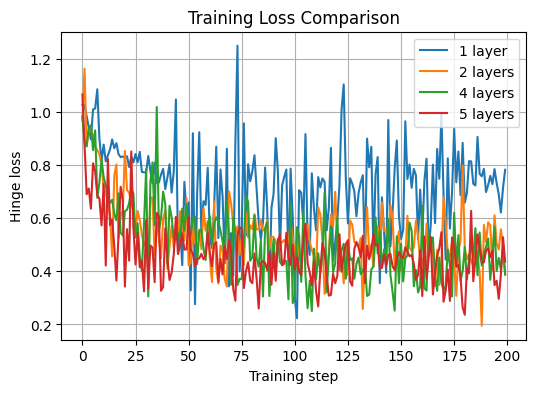

In [29]:
plt.figure(figsize=(6,4))

plt.plot(history_1, label="1 layer")
plt.plot(history_2, label="2 layers")
plt.plot(history_4, label="4 layers")
plt.plot(history_5, label="5 layers")
# plt.plot(history_6, label="6 layers")

plt.xlabel("Training step")
plt.ylabel("Hinge loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

Minibatching makes everything noisy, so I'm gonna use smoothing to reveal the actual trend.

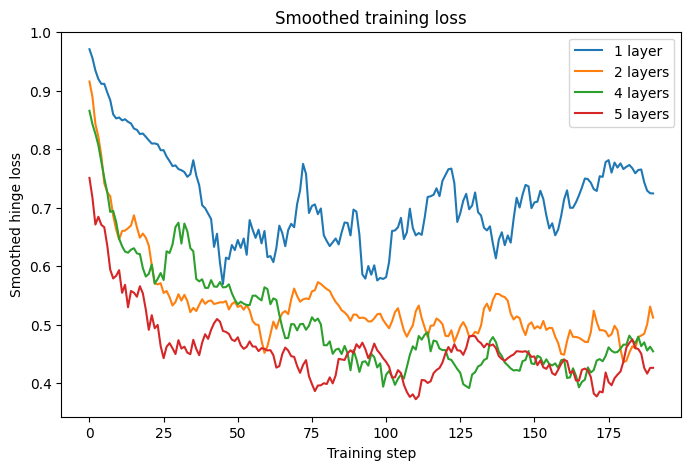

In [30]:
def smooth(x, w=10):
    return np.convolve(x, np.ones(w) / w, mode="valid")

plt.figure(figsize=(8,5))
plt.plot(smooth(history_1), label="1 layer")
plt.plot(smooth(history_2), label="2 layers")
plt.plot(smooth(history_4), label="4 layers")
plt.plot(smooth(history_5), label="5 layers")
# plt.plot(smooth(history_6), label="6 layers")

plt.xlabel("Training step")
plt.ylabel("Smoothed hinge loss")
plt.title("Smoothed training loss")
plt.legend()
plt.grif=True

plt.show()

There's also Mean Loss per Model I can compare...

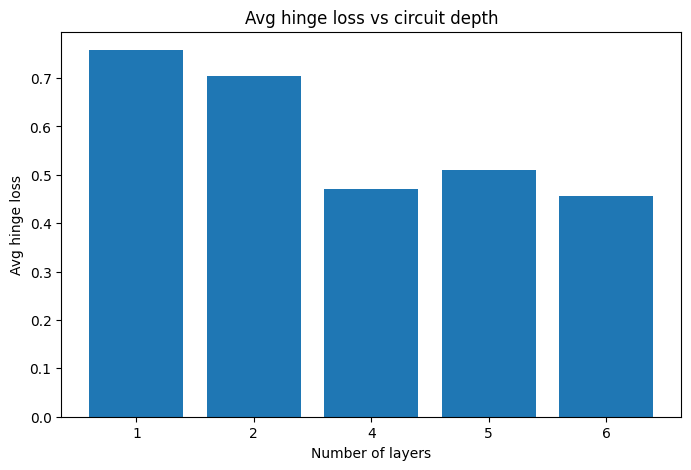

In [32]:
means = [np.mean(history_1), np.mean(history_2), np.mean(history_4), np.mean(history_5), np.mean(history_6)]

layers = ["1", "2", "4", "5", "6"]

plt.figure(figsize=(8,5))
plt.bar(layers, means)

plt.xlabel("Number of layers")
plt.ylabel("Avg hinge loss")
plt.title("Avg hinge loss vs circuit depth")

plt.show()

Loss distribution


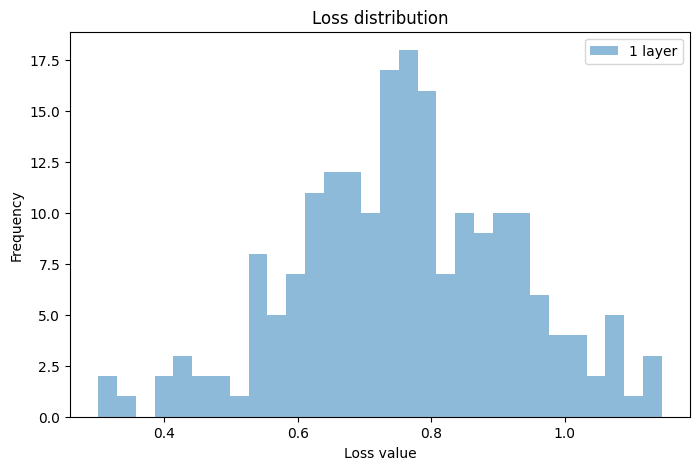

In [42]:
plt.figure(figsize=(8,5))

plt.hist(history_1, bins=30, alpha=0.5, label="1 layer")
# plt.hist(history_2, bins=30, alpha=0.5, label="2 layers")
# plt.hist(history_4, bins=30, alpha=0.5, label="4 layers")
# plt.hist(history_5, bins=30, alpha=0.5, label="5 layers")
# plt.hist(history_6, bins=30, alpha=0.5, label="6 layers")

plt.xlabel("Loss value")
plt.ylabel("Frequency")
plt.title("Loss distribution")

plt.legend()
plt.show()

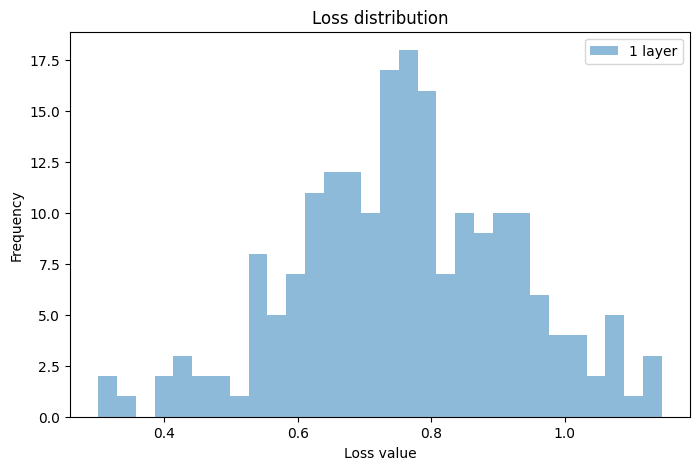

In [43]:
plt.figure(figsize=(8,5))

plt.hist(history_1, bins=30, alpha=0.5, label="1 layer")
# plt.hist(history_2, bins=30, alpha=0.5, label="2 layers")
# plt.hist(history_4, bins=30, alpha=0.5, label="4 layers")
# plt.hist(history_5, bins=30, alpha=0.5, label="5 layers")
# plt.hist(history_6, bins=30, alpha=0.5, label="6 layers")

plt.xlabel("Loss value")
plt.ylabel("Frequency")
plt.title("Loss distribution")

plt.legend()
plt.show()

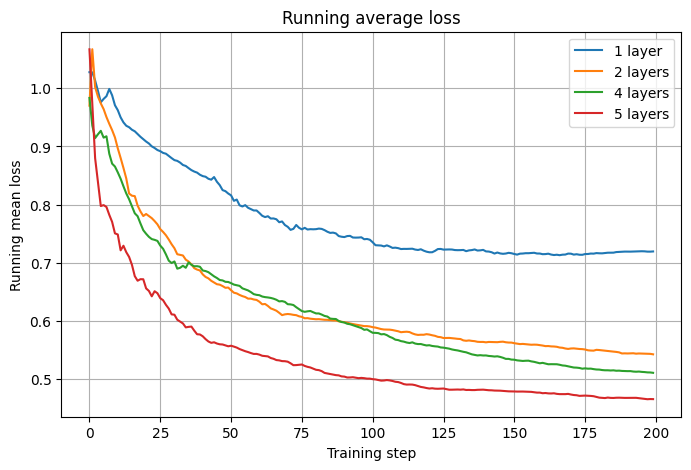

In [31]:
def running_mean(x):
    return np.cumsum(x) / np.arange(1, len(x) + 1)

plt.figure(figsize=(8,5))

plt.plot(running_mean(history_1), label="1 layer")
plt.plot(running_mean(history_2), label="2 layers")
plt.plot(running_mean(history_4), label="4 layers")
plt.plot(running_mean(history_5), label="5 layers")
# plt.plot(running_mean(history_6), label="6 layers")

plt.xlabel("Training step")
plt.ylabel("Running mean loss")
plt.title("Running average loss")

plt.legend()
plt.grid(True)

plt.show()